# Proyecto final: dataset real $4\times 4$ → QUBO → QAOA local y hardware opcional

Qubit.mx - QMexico Summer School 2026.

El objetivo del proyecto es transformar un problema real o semi-real bien justificado en un problema de **matching bipartito**, formularlo como **QUBO** y resolver una instancia pequeña con **QAOA local**. La ejecución en hardware real de IBM Quantum es opcional y avanzada.

La calificación está cargada hacia el modelado de datos:

- **≈80%**: encontrar, justificar y documentar un dataset real o semi-real de tamaño $4\times 4$.
- **≈20%**: implementar correctamente el pipeline `QUBO → validación clásica → QAOA local`; la comparación con hardware real solo cuenta como extensión avanzada si fue autorizada.

La instancia molecular incluida aquí es solo un **ejemplo educativo** para probar el código. Para que el proyecto final cuente y pueda evaluarse en el curso, cada equipo debe sustituirla por su propio dataset real o semi-real documentado.

## Entorno de ejecución en Google Colab

Ejecuten la siguiente celda al iniciar la sesión. Instala las librerías científicas usadas en el pipeline local y las librerías de Qiskit necesarias para la sección avanzada de IBM Quantum.

La parte base del proyecto no requiere cuenta de IBM Quantum. Qiskit se instala para evitar errores de importación si el equipo decide ejecutar la sección opcional de hardware real.

In [1]:
%%capture
%pip -q install numpy pandas scipy matplotlib qiskit qiskit-aer qiskit-ibm-runtime pylatexenc

## 0. Lectura operativa de la rúbrica

Este proyecto no evalúa únicamente si el código corre. Evalúa si el equipo puede hacer una traducción razonada:

```text
datos reales → entidades A y B → score S_ij → variables binarias x_ij → restricciones → QUBO → solución
```

La pregunta central no es “¿qué dataset encontré?”, sino:

> ¿Por qué este dataset puede modelarse de forma honesta como un matching bipartito 4×4?

## 1. Modelo matemático mínimo

Sean dos conjuntos de tamaño 4:

$$
A = \{a_1,a_2,a_3,a_4\}, \qquad
B = \{b_1,b_2,b_3,b_4\}.
$$

Cada variable binaria indica si se elige un emparejamiento entre $a_i$ y $b_j$:

$$
x_{ij}=\begin{cases}
1, & \text{si } a_i \text{ se asigna a } b_j,\\
0, & \text{en otro caso.}
\end{cases}
$$

La matriz $S\in\mathbb{R}^{4\times 4}$ contiene el beneficio, compatibilidad o score de cada posible match:

$$
S_{ij}=\text{score de asignar } a_i \text{ con } b_j.
$$

## 2. Objetivo y restricciones

El problema de asignación uno-a-uno busca maximizar el score total:

$$
\max_x \sum_{i=1}^{4}\sum_{j=1}^{4} S_{ij}x_{ij}.
$$

Restricción por filas: cada elemento de $A$ se asigna exactamente una vez.

$$
\sum_{j=1}^{4} x_{ij}=1 \qquad \forall i\in\{1,2,3,4\}.
$$

Restricción por columnas: cada elemento de $B$ recibe exactamente una asignación.

$$
\sum_{i=1}^{4} x_{ij}=1 \qquad \forall j\in\{1,2,3,4\}.
$$

## 3. Formulación QUBO

Un QUBO es una minimización cuadrática binaria. Convertimos el problema anterior en:

$$
E(x)=
-\sum_{i=1}^{4}\sum_{j=1}^{4} S_{ij}x_{ij}
+\lambda_A\sum_{i=1}^{4}\left(\sum_{j=1}^{4} x_{ij}-1\right)^2
+\lambda_B\sum_{j=1}^{4}\left(\sum_{i=1}^{4} x_{ij}-1\right)^2.
$$

El primer término premia scores altos. Los términos con $\lambda_A$ y $\lambda_B$ penalizan violaciones de las restricciones.

Si las penalizaciones son suficientemente grandes, el mínimo del QUBO corresponde a una asignación factible de alto score.

# Parte A — Búsqueda y justificación del dataset

Esta parte vale aproximadamente el 80% de la nota. Debe quedar documentada antes de ejecutar QAOA.

## 4. Criterios de un dataset apto para QUBO

Un dataset es apto si permite contestar claramente estas preguntas:

| Criterio | Pregunta que debe responder el equipo |
|---|---|
| Dos lados identificables | ¿Qué será $A$ y qué será $B$? |
| Tamaño reducible a $4\times 4$ | ¿Cómo se seleccionan exactamente 4 elementos de cada lado? |
| Score justificable | ¿Cómo se calcula $S_{ij}$ con columnas observables o reglas explícitas? |
| Decisión binaria | ¿Qué significa $x_{ij}=1$? |
| Restricciones claras | ¿Cada elemento se usa una vez, a lo más una vez, o hay capacidades? |
| Fuente legítima | ¿La fuente, institución, URL, licencia y fecha de consulta están documentadas? |
| Riesgo ético controlado | ¿No se usan datos personales sensibles ni se simulan decisiones reales de alto impacto? |

Un dataset no es apto si solo contiene una serie temporal sin entidades asignables, si no tiene una fuente verificable, si no permite construir un score $S_{ij}$, o si requiere datos personales identificables.

## 5. Portales mexicanos recomendados

Estos portales son puntos de partida. El equipo debe revisar fuente, licencia, campos disponibles, granularidad, fecha de actualización y riesgos éticos.

| Portal | Qué buscar | Posible $A$ vs $B$ | Ejemplo de score $S_{ij}$ |
|---|---|---|---|
| [SNIIV / SEDATU](https://sniiv.sedatu.gob.mx/) | Vivienda, rezago habitacional, financiamientos, inventario y subsidios. | Zonas o municipios vs tipos de vivienda, subsidios o programas. | Ajuste entre demanda, rezago, inventario y disponibilidad. |
| [Datos Abiertos CDMX](https://datos.cdmx.gob.mx/) | Servicios urbanos, atención ciudadana, movilidad, seguridad, cultura. | Alcaldías o colonias vs servicios, cuadrillas, recursos o programas. | Prioridad basada en solicitudes, rezago, cobertura y severidad. |

El objetivo no es descargar una base grande. El objetivo es justificar una **subinstancia $4\times 4$** extraída con reglas claras.

## 6. Dominios aplicables en México

**Vivienda.** Posible modelado: $A=$ municipios o zonas; $B=$ programas, tipos de vivienda o subsidios. El score puede combinar rezago habitacional, inventario, financiamiento y cobertura.



## 7. Cómo convertir un dataset real en una matriz $4\times 4$

Procedimiento mínimo recomendado:

1. Elegir un dominio y una fuente oficial.
2. Definir qué entidades serán $A$ y qué entidades serán $B$.
3. Filtrar exactamente 4 elementos de cada lado con una regla reproducible.
4. Definir $x_{ij}=1$ en lenguaje del dominio.
5. Construir $S_{ij}$ con una fórmula explícita.
6. Normalizar las columnas usadas para que ninguna domine artificialmente.
7. Documentar restricciones: uno-a-uno, a lo más uno, capacidades o exclusiones.
8. Auditar riesgos éticos y sesgos.

Ejemplo de score semi-real:

$$
S_{ij}=0.5\,z(\mathrm{demanda}_{ij})+0.3\,z(\mathrm{cobertura}_{ij})-0.2\,z(\mathrm{distancia}_{ij}).
$$

Donde $z(\cdot)$ puede ser una normalización min-max o una estandarización.

## 8. Formato obligatorio de entrega: repositorio GitHub

La entrega es un enlace a un repositorio de GitHub creado desde el perfil del estudiante o del equipo. Si el repositorio es privado, debe compartirse con el docente antes de la fecha límite.

Estructura mínima del repositorio:

```text
nombre-del-repositorio/
├── data/
│   └── dataset_real_4x4.csv
├── README.md
└── proyecto_qubo_qaoa.ipynb
```

Requisitos obligatorios:

1. La carpeta `data/` debe contener el CSV real o semi-real usado por el equipo.
2. El archivo `README.md` debe justificar el dataset, explicar la formulación QUBO y reportar la comparación entre la solución clásica y QAOA.
3. El archivo `.ipynb` debe poder abrirse en Google Colab y ejecutar todas las celdas en orden con `Runtime → Run all` sin errores intermedios.
4. La instancia molecular de ejemplo no cuenta como dataset del proyecto final. Puede conservarse como respaldo, pero la entrega evaluable debe usar el CSV del equipo.
5. Si el archivo `.ipynb` se abre directamente desde GitHub en Colab, el equipo debe asegurarse de que el CSV pueda leerse sin intervención manual, por ejemplo mediante una URL raw del archivo `data/dataset_real_4x4.csv` o mediante una celda clara de clonación del repositorio.
6. No se deben subir tokens personales, credenciales, archivos privados ni datos sensibles.

Contenido mínimo del `README.md`:

```text
# Proyecto QUBO-QAOA: matching bipartito 4x4

## Dataset
Nombre del dataset:
Fuente oficial o confiable:
Institución responsable:
URL de la fuente:
URL raw del CSV usado en data/:
Licencia o condiciones de uso:
Fecha de consulta:
Dominio del problema:

## Modelado
Conjunto A:
Criterio para elegir exactamente 4 elementos de A:
Conjunto B:
Criterio para elegir exactamente 4 elementos de B:
Definición de x_ij = 1:
Interpretación de x_ij = 0:

## Matriz de score
Columnas usadas:
Fórmula exacta de S_ij:
Normalización aplicada:
Matriz S 4x4:

## Restricciones
Restricción por filas:
Restricción por columnas:
Otras restricciones, si existen:
Justificación de por qué el problema es matching bipartito:
Justificación de por qué es razonable modelarlo como QUBO:

## Resultados
Solución clásica exacta:
Resultado QAOA local:
Comparación clásico vs QAOA local:
Si se usó hardware real o pipeline híbrido, comparación adicional:

## Ética y limitaciones
Riesgos éticos:
Medidas de mitigación:
Limitaciones del modelo:

## Ejecución
Instrucciones para abrir el archivo .ipynb en Google Colab:
Instrucciones para ejecutar todas las celdas sin errores:
```

## 9. Advertencia ética

Este proyecto es educativo. No debe usarse para tomar decisiones reales sobre salud, trasplantes, vivienda, empleo, seguridad, becas, apoyos públicos ni asignación de recursos.

Reglas mínimas:

- No usar nombres, CURP, expedientes, domicilios, teléfonos ni identificadores personales.
- No usar datos sensibles individuales.
- Preferir datos agregados por municipio, entidad, institución o categoría.
- Explicar sesgos potenciales del dataset.
- No presentar la salida de QAOA como recomendación normativa.
- Si el dominio es de alto impacto, usar perfiles sintéticos o agregados.

# Parte B — Pipeline computacional local

Esta parte vale aproximadamente el 20% de la nota. Debe ejecutarse localmente en Google Colab sin saturar memoria.

La implementación local usa simulación vectorial de QAOA con $2^{16}=65\,536$ amplitudes complejas. Esto es pequeño para Colab.

## 11. Importaciones y configuración

Objetivo: cargar librerías y fijar una semilla reproducible.

In [55]:
#------------------------------------
# Importaciones y modificaciones
#------------------------------------

from collections import Counter
from itertools import permutations
from pathlib import Path
from typing import Any
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize, linear_sum_assignment
from IPython.display import display

# Semilla para reproducibilidad
SEED = 2026
rng = np.random.default_rng(SEED)

# Dimensiones del problema
N_MUNICIPIOS = 4
N_MODALIDADES = 4
N_VARS = N_MUNICIPIOS * N_MODALIDADES # 16 variables binarias
N_A = N_MUNICIPIOS
N_B = N_MODALIDADES
N_VARS = N_A * N_B

## 12. Dataset molecular educativo $4\times 4$

Esta instancia molecular permite verificar que el pipeline computacional funciona de inicio a fin.

Debe quedar claro en el reporte: **la molécula no es el dataset del proyecto final**. El equipo debe reemplazar `A_df`, `B_df` y `S` por una instancia $4\times 4$ construida a partir de su dataset real o semi-real. Si entregan únicamente la molécula de ejemplo, la parte central del proyecto no queda validada.

In [3]:
A_df = pd.DataFrame([
    {"id":"A1","Municipio":"Puebla","Con_Rezago":33147,
     "Sin_Rezago":436797,"Rezago":7.05},

    {"id":"A2","Municipio":"Tehuacán","Con_Rezago":20156,
     "Sin_Rezago":64501,"Rezago":23.81},

    {"id":"A3","Municipio":"Atlixco","Con_Rezago":7957,
     "Sin_Rezago":27283,"Rezago":22.58},

    {"id":"A4","Municipio":"Huauchinango","Con_Rezago":11911,
     "Sin_Rezago":15847,"Rezago":42.90},
]).set_index("id")

display(A_df)

,Municipio,Con_Rezago,Sin_Rezago,Rezago
id,,,,
A1,Puebla,33147,436797,7.05
A2,Tehuacán,20156,64501,23.81
A3,Atlixco,7957,27283,22.58
A4,Huauchinango,11911,15847,42.90


In [4]:
B_df = pd.DataFrame([
    {"id":"B1","Modalidad":"Vivienda Nueva"},
    {"id":"B2","Modalidad":"Vivienda Existente"},
    {"id":"B3","Modalidad":"Mejoramiento"},
    {"id":"B4","Modalidad":"Otros Programas"},
]).set_index("id")

display(B_df)

,Modalidad
id,
B1,Vivienda Nueva
B2,Vivienda Existente
B3,Mejoramiento
B4,Otros Programas


## 13. La Matriz S
La matriz de afinidad será:

 $S_ij​=0.6z_r​(i)+0.4z_a​(i,j)$

donde:

$z_r(i)$: rezago habitacional normalizado del municipio i.

$z_a(i,j)$: acciones históricas normalizadas de la modalidad j en el municipio i.


## 14. Regla de score molecular

Objetivo: construir $S_{ij}$ con una regla transparente.

La regla premia cargas opuestas, compatibilidad donor-acceptor, similitud hidrofóbica, aromaticidad y polaridad. Penaliza diferencias de tamaño.

In [76]:
# ==========================================
# 14. Construcción de la matriz de scores S
# ==========================================

# Normalizar el porcentaje de rezago (Min-Max)
rezago = A_df["Rezago"].to_numpy(dtype=float)

rezago_norm = (rezago - rezago.min()) / (rezago.max() - rezago.min())

A_df["Rezago_Normalizado"] = rezago_norm

# Obtener la matriz de acciones históricas
acciones = actions_df[
    [
        "Vivienda_Nueva",
        "Vivienda_Existente",
        "Mejoramiento",
        "Otros_Programas",
    ]
].to_numpy(dtype=float)

# Normalización Min-Max de las acciones
acciones_norm = (
    acciones - acciones.min()
) / (
    acciones.max() - acciones.min()
)

KeyError: 'Rezago'

In [84]:
A_df = pd.DataFrame({
    "Municipio": ["Puebla", "Tehuacán", "Atlixco", "Huauchinango"],
    "Con_Rezago": [33147, 20156, 7957, 11911],
    "Sin_Rezago": [436797, 64501, 27283, 15847]
})

A_df["Porcentaje_Rezago"] = (
    A_df["Con_Rezago"] /
    (A_df["Con_Rezago"] + A_df["Sin_Rezago"])
) * 100

A_df = A_df.set_index("Municipio")

## 15. Punto de reemplazo para el dataset del equipo

Esta es la sección donde cada equipo debe sustituir el ejemplo molecular por su dataset.

Deben mantener tres objetos con el mismo formato:

- `A_df`: tabla con exactamente 4 elementos del lado $A$.
- `B_df`: tabla con exactamente 4 elementos del lado $B$.
- `S`: matriz numérica $4\times 4$ con el score $S_{ij}$.

La carga recomendada para la entrega final es leer el CSV desde `data/dataset_real_4x4.csv`. El formato más simple es una tabla larga con estas columnas:

```text
a_id,b_id,score
A1,B1,7.5
A1,B2,3.0
...
A4,B4,8.0
```

También pueden agregar columnas opcionales como `a_nombre` y `b_nombre` para mostrar etiquetas más legibles.

La matriz `S` debe salir de una fórmula justificada en el `README.md`, no de valores arbitrarios. Para que el proyecto final sea contado y validado para el curso, esta sección debe cargar o definir la instancia construida a partir del dataset real o semi-real del equipo.

In [75]:
# Carga recomendada para la entrega final.
# Si existe data/dataset_real_4x4.csv, se carga automáticamente.
# Si el archivo .ipynb se abre directamente desde GitHub en Colab, pueden pegar la URL raw del CSV.

DATASET_CSV_PATH = Path("data/dataset_real_4x4.csv")
DATASET_CSV_URL = "https://raw.githubusercontent.com/JesusFPecu/quantum-housing-allocation/refs/heads/main/data/dataset_real_4x4.csv"  #@param {type:"string"}

CARGAR_DATASET_REAL = DATASET_CSV_PATH.exists() or bool(DATASET_CSV_URL.strip())

if CARGAR_DATASET_REAL:
    if DATASET_CSV_PATH.exists():
        raw_dataset_df = pd.read_csv(DATASET_CSV_PATH)
        dataset_source = str(DATASET_CSV_PATH)
    else:
        raw_dataset_df = pd.read_csv(DATASET_CSV_URL.strip())
        dataset_source = DATASET_CSV_URL.strip()

    required_columns = {"a_id", "b_id", "score"}
    missing = required_columns - set(raw_dataset_df.columns)
    if missing:
        raise ValueError(f"El CSV debe contener las columnas {required_columns}. Faltan: {missing}")

    raw_dataset_df = raw_dataset_df.copy()
    raw_dataset_df["a_id"] = raw_dataset_df["a_id"].astype(str)
    raw_dataset_df["b_id"] = raw_dataset_df["b_id"].astype(str)
    raw_dataset_df["score"] = pd.to_numeric(raw_dataset_df["score"], errors="raise")

    if raw_dataset_df.duplicated(subset=["a_id", "b_id"]).any():
        raise ValueError("El CSV tiene pares duplicados (a_id, b_id). Debe haber exactamente un score por par.")

    a_values = list(pd.unique(raw_dataset_df["a_id"]))
    b_values = list(pd.unique(raw_dataset_df["b_id"]))

    if len(a_values) != 4 or len(b_values) != 4:
        raise ValueError("El CSV debe definir exactamente 4 valores únicos de a_id y 4 valores únicos de b_id.")

    S_loaded_df = raw_dataset_df.pivot(index="a_id", columns="b_id", values="score").loc[a_values, b_values]
    if S_loaded_df.shape != (4, 4) or S_loaded_df.isna().any().any():
        raise ValueError("El CSV debe contener exactamente un score para cada par (a_id, b_id).")

    A_df = pd.DataFrame({"id": a_values}).set_index("id")
    B_df = pd.DataFrame({"id": b_values}).set_index("id")

    if "a_nombre" in raw_dataset_df.columns:
        A_df["nombre"] = raw_dataset_df.groupby("a_id")["a_nombre"].first().loc[a_values].values
    if "b_nombre" in raw_dataset_df.columns:
        B_df["nombre"] = raw_dataset_df.groupby("b_id")["b_nombre"].first().loc[b_values].values

    S = S_loaded_df.to_numpy(dtype=float)
    S_df = pd.DataFrame(S, index=A_df.index, columns=B_df.index)
    USANDO_DATASET_MOLECULAR_DE_EJEMPLO = False
    NOMBRE_INSTANCIA = dataset_source

    print("Dataset real/semi-real cargado:", NOMBRE_INSTANCIA)
    display(A_df)
    display(B_df)
    display(S_df)
else:
    USANDO_DATASET_MOLECULAR_DE_EJEMPLO = True
    NOMBRE_INSTANCIA = "molecular_educativa_de_respaldo"
    print("No se encontró data/dataset_real_4x4.csv ni DATASET_CSV_URL. Se mantiene la instancia molecular de ejemplo.")

# Alternativa manual: si no usan CSV, pueden asignar A_df, B_df y S directamente aquí,
# siempre que documenten la fuente y la construcción de S en el README.md del repositorio.

Dataset real/semi-real cargado: https://raw.githubusercontent.com/JesusFPecu/quantum-housing-allocation/refs/heads/main/data/dataset_real_4x4.csv


""
id
A1
A2
A3
A4


""
id
B1
B2
B3
B4


id,B1,B2,B3,B4
id,,,,
A1,0.62,0.55,0.40,0.48
A2,0.70,0.60,0.52,0.58
A3,0.68,0.57,0.50,0.60
A4,0.85,0.75,0.65,0.72


In [67]:
import numpy as np
import pandas as pd

# ============================
# 1. DATOS MANUALES (TU CASO)
# ============================

A_df = pd.DataFrame({
    "Municipio": [
        "Puebla",
        "Tehuacán",
        "Atlixco",
        "Huauchinango"
    ],
    "Porcentaje_Rezago": [
        7.05,
        23.81,
        22.58,
        42.90
    ]
}).set_index("Municipio")

B_df = pd.DataFrame({
    "modalidad": [
        "Vivienda_Nueva",
        "Vivienda_Existente",
        "Mejoramiento",
        "Otros_Programas"
    ]
}).set_index("modalidad")

actions_df = pd.DataFrame({
    "Vivienda_Nueva": [1245, 698, 502, 280],
    "Vivienda_Existente": [864, 415, 301, 194],
    "Mejoramiento": [392, 310, 228, 257],
    "Otros_Programas": [110, 82, 74, 61]
}, index=A_df.index)

# ============================
# 2. NORMALIZACIÓN REZAGO
# ============================

rezago = A_df["Porcentaje_Rezago"].to_numpy(dtype=float)
rezago_norm = (rezago - rezago.min()) / (rezago.max() - rezago.min())

# ============================
# 3. NORMALIZACIÓN ACCIONES
# ============================

acciones = actions_df.to_numpy(dtype=float)

min_a = acciones.min()
max_a = acciones.max()

if max_a - min_a == 0:
    acciones_norm = np.zeros_like(acciones)
else:
    acciones_norm = (acciones - min_a) / (max_a - min_a)

# ============================
# 4. MATRIZ S FINAL
# ============================

S = np.zeros((4, 4), dtype=float)

for i in range(4):
    for j in range(4):
        S[i, j] = (
            0.6 * rezago_norm[i] +
            0.4 * acciones_norm[i, j]
        )

S_df = pd.DataFrame(S, index=A_df.index, columns=B_df.index)

display(S_df.round(3))

modalidad,Vivienda_Nueva,Vivienda_Existente,Mejoramiento,Otros_Programas
Municipio,,,,
Puebla,0.400,0.271,0.112,0.017
Tehuacán,0.496,0.400,0.365,0.288
Atlixco,0.409,0.341,0.316,0.264
Huauchinango,0.674,0.645,0.666,0.600


## 16. Validación mínima del dataset

Objetivo: detener la ejecución si la instancia no tiene tamaño $4\times 4$ o contiene valores no numéricos.

In [8]:
assert len(A_df) == 4, "A_df debe tener exactamente 4 filas."
assert len(B_df) == 4, "B_df debe tener exactamente 4 filas."
assert S.shape == (4, 4), "S debe tener forma (4, 4)."
assert np.isfinite(S).all(), "S contiene valores no finitos."

print("Dataset validado: A_df, B_df y S tienen formato compatible con matching 4x4.")

Dataset validado: A_df, B_df y S tienen formato compatible con matching 4x4.


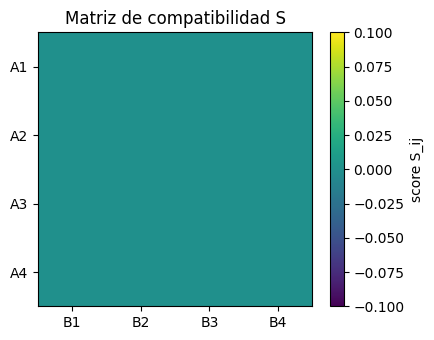

In [9]:
plt.figure(figsize=(4.5, 3.5))
plt.imshow(S)
plt.xticks(range(N_B), B_df.index)
plt.yticks(range(N_A), A_df.index)
plt.colorbar(label="score S_ij")
plt.title("Matriz de compatibilidad S")
plt.tight_layout()
plt.show()

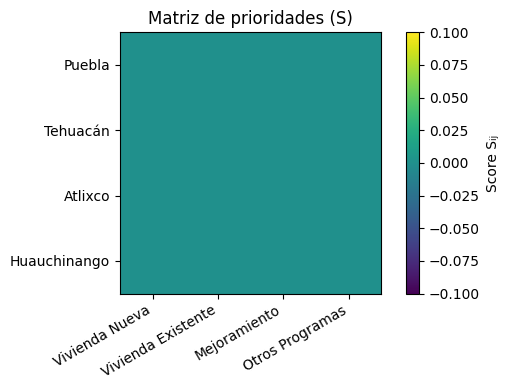

In [10]:
# Visualización de la matriz de scores
plt.figure(figsize=(6,4))

plt.imshow(S)

plt.xticks(
    range(N_MODALIDADES),
    B_df["Modalidad"],
    rotation=30,
    ha="right"
)

plt.yticks(
    range(N_MUNICIPIOS),
    A_df["Municipio"]
)

plt.colorbar(label="Score Sᵢⱼ")

plt.title("Matriz de prioridades (S)")
plt.tight_layout()
plt.show()

## 17. Variables binarias $x_{ij}$

Objetivo: mapear cada posible match a una variable binaria y a un qubit lógico.

In [11]:
def var_index(i: int, j: int, n_b: int = N_B) -> int:
    return i * n_b + j

variables = []
for i, a_id in enumerate(A_df.index):
    for j, b_id in enumerate(B_df.index):
        variables.append({
            "k": var_index(i, j),
            "variable": f"x_{a_id}_{b_id}",
            "A": a_id,
            "B": b_id,
            "score": S[i, j],
        })

variables_df = pd.DataFrame(variables).set_index("k")
display(variables_df)

,variable,A,B,score
k,,,,
0,x_A1_B1,A1,B1,0.0
1,x_A1_B2,A1,B2,0.0
2,x_A1_B3,A1,B3,0.0
3,x_A1_B4,A1,B4,0.0
4,x_A2_B1,A2,B1,0.0
5,x_A2_B2,A2,B2,0.0
6,x_A2_B3,A2,B3,0.0
7,x_A2_B4,A2,B4,0.0
8,x_A3_B1,A3,B1,0.0


In [12]:
# ==========================================
# 17. Variables binarias x_ij
# ==========================================

def var_index(i: int, j: int, n_modalidades: int = N_MODALIDADES) -> int:
    return i * n_modalidades + j

variables = []

for i, municipio in enumerate(A_df["Municipio"]):
    for j, modalidad in enumerate(B_df["Modalidad"]):
        variables.append({
            "k": var_index(i, j),
            "variable": f"x_{i+1}_{j+1}",
            "Municipio": municipio,
            "Modalidad": modalidad,
            "score": S[i, j],
        })

variables_df = pd.DataFrame(variables).set_index("k")

display(variables_df)

,variable,Municipio,Modalidad,score
k,,,,
0,x_1_1,Puebla,Vivienda Nueva,0.0
1,x_1_2,Puebla,Vivienda Existente,0.0
2,x_1_3,Puebla,Mejoramiento,0.0
3,x_1_4,Puebla,Otros Programas,0.0
4,x_2_1,Tehuacán,Vivienda Nueva,0.0
5,x_2_2,Tehuacán,Vivienda Existente,0.0
6,x_2_3,Tehuacán,Mejoramiento,0.0
7,x_2_4,Tehuacán,Otros Programas,0.0
8,x_3_1,Atlixco,Vivienda Nueva,0.0


## 18. Penalización QUBO
Objetivo: elegir penalizaciones suficientemente grandes para que violar restricciones sea más costoso que ganar score.

La regla usada aquí es conservadora para una instancia educativa pequeña.

In [69]:
# ==========================================
# 18. Penalización QUBO
# ==========================================

# Selección automática de los parámetros de penalización.
# Las penalizaciones deben ser suficientemente grandes para
# que cualquier solución que viole las restricciones tenga
# un costo mayor que la ganancia obtenida por la función objetivo.

def choose_penalty(score_matrix: np.ndarray) -> float:
    max_abs_score = float(np.max(np.abs(score_matrix)))
    return float(math.ceil(4.0 * max_abs_score + 1.0))

LAMBDA_A = choose_penalty(S)
LAMBDA_B = choose_penalty(S)

print("lambda_A =", LAMBDA_A)
print("lambda_B =", LAMBDA_B)

lambda_A = 4.0
lambda_B = 4.0


## 19. Construcción del QUBO

Usaremos la convención:

$$
E(x)=\sum_k Q_{kk}x_k+\sum_{k<\ell}Q_{k\ell}x_kx_\ell+\mathrm{offset}.
$$

`Q` guarda la diagonal y la parte triangular superior.

La función objetivo maximiza la matriz de prioridades S.
Las restricciones garantizan que:
1. Cada municipio reciba exactamente una modalidad.
 2. Cada modalidad se asigne exactamente a un municipio.

In [14]:
def add_exactly_one_penalty(Q: np.ndarray, group: list[int], penalty: float) -> float:
    """Agrega penalty * (sum(group) - 1)^2 al QUBO."""
    offset = float(penalty)

    for k in group:
        Q[k, k] += -penalty

    for pos, k in enumerate(group):
        for l in group[pos + 1:]:
            Q[k, l] += 2.0 * penalty

    return offset

In [15]:
def build_assignment_qubo(score_matrix: np.ndarray, lambda_a: float, lambda_b: float):
    S_local = np.asarray(score_matrix, dtype=float)
    n_a, n_b = S_local.shape
    Q = np.zeros((n_a * n_b, n_a * n_b), dtype=float)
    offset = 0.0

    for i in range(n_a):
        for j in range(n_b):
            k = var_index(i, j, n_b)
            Q[k, k] += -S_local[i, j]

    for i in range(n_a):
        group = [var_index(i, j, n_b) for j in range(n_b)]
        offset += add_exactly_one_penalty(Q, group, lambda_a)

    for j in range(n_b):
        group = [var_index(i, j, n_b) for i in range(n_a)]
        offset += add_exactly_one_penalty(Q, group, lambda_b)

    return Q, float(offset)

In [16]:
Q, qubo_offset = build_assignment_qubo(S, LAMBDA_A, LAMBDA_B)

print("Variables binarias:", N_VARS)
print("Offset QUBO:", qubo_offset)
print("Términos no nulos en Q:", int(np.count_nonzero(np.abs(Q) > 1e-12)))

Variables binarias: 16
Offset QUBO: 8.0
Términos no nulos en Q: 64


In [17]:
def qubo_terms_dataframe(Q: np.ndarray) -> pd.DataFrame:
    rows = []
    n = Q.shape[0]
    for k in range(n):
        if abs(Q[k, k]) > 1e-12:
            rows.append({"tipo": "lineal", "k": k, "l": k, "coeficiente": Q[k, k]})
        for l in range(k + 1, n):
            if abs(Q[k, l]) > 1e-12:
                rows.append({"tipo": "cuadrático", "k": k, "l": l, "coeficiente": Q[k, l]})
    return pd.DataFrame(rows)

qubo_terms_df = qubo_terms_dataframe(Q)
display(qubo_terms_df.head(20))

,tipo,k,l,coeficiente
0,lineal,0,0,-2.0
1,cuadrático,0,1,2.0
2,cuadrático,0,2,2.0
3,cuadrático,0,3,2.0
4,cuadrático,0,4,2.0
5,cuadrático,0,8,2.0
6,cuadrático,0,12,2.0
7,lineal,1,1,-2.0
8,cuadrático,1,2,2.0
9,cuadrático,1,3,2.0


## 20. Funciones de energía e interpretación

Objetivo: evaluar el QUBO, reconstruir matrices de asignación y revisar restricciones.

In [18]:
def qubo_energy(x: np.ndarray, Q: np.ndarray, offset: float = 0.0) -> float:
    x = np.asarray(x, dtype=int)
    energy = float(offset)

    for k in range(len(x)):
        energy += Q[k, k] * x[k]

    for k in range(len(x)):
        for l in range(k + 1, len(x)):
            energy += Q[k, l] * x[k] * x[l]

    return float(energy)


def assignment_matrix(x: np.ndarray) -> np.ndarray:
    return np.asarray(x, dtype=int).reshape(N_A, N_B)

In [19]:
def is_feasible(x: np.ndarray) -> bool:
    M = assignment_matrix(x)
    return bool((M.sum(axis=1) == 1).all() and (M.sum(axis=0) == 1).all())


def assignment_score(x: np.ndarray, score_matrix: np.ndarray = S) -> float:
    return float(np.sum(assignment_matrix(x) * score_matrix))


def selected_pairs(x: np.ndarray) -> pd.DataFrame:
    M = assignment_matrix(x)
    rows = []
    for i, a_id in enumerate(A_df.index):
        for j, b_id in enumerate(B_df.index):
            if M[i, j] == 1:
                rows.append({"A": a_id, "B": b_id, "score": S[i, j]})
    return pd.DataFrame(rows)

In [70]:
# ==========================================
# 20. Funciones de energía e interpretación
# ==========================================

def qubo_energy(x: np.ndarray, Q: np.ndarray, offset: float = 0.0) -> float:
    """
    Calcula la energía de una solución binaria x
    para el modelo QUBO.
    """
    x = np.asarray(x, dtype=int)
    energy = float(offset)

    # Términos lineales
    for k in range(len(x)):
        energy += Q[k, k] * x[k]

    # Términos cuadráticos
    for k in range(len(x)):
        for l in range(k + 1, len(x)):
            energy += Q[k, l] * x[k] * x[l]

    return float(energy)


def assignment_matrix(x: np.ndarray) -> np.ndarray:
    """
    Reconstruye la matriz Municipio × Modalidad
    a partir del vector binario.
    """
    return np.asarray(x, dtype=int).reshape(
        N_MUNICIPIOS,
        N_MODALIDADES
    )


def is_feasible(x: np.ndarray) -> bool:
    """
    Verifica que la solución cumpla las restricciones:
    - Cada municipio recibe exactamente una modalidad.
    - Cada modalidad se asigna exactamente una vez.
    """
    M = assignment_matrix(x)

    return bool(
        (M.sum(axis=1) == 1).all() and
        (M.sum(axis=0) == 1).all()
    )


def assignment_score(
    x: np.ndarray,
    score_matrix: np.ndarray = S
) -> float:
    """
    Calcula el score total de una asignación.
    """
    return float(
        np.sum(
            assignment_matrix(x) * score_matrix
        )
    )


def selected_pairs(x: np.ndarray) -> pd.DataFrame:
    """
    Devuelve la asignación Municipio → Modalidad
    correspondiente al vector binario x.
    """
    M = assignment_matrix(x)

    rows = []

    for i, municipio in enumerate(A_df["Municipio"]):
        for j, modalidad in enumerate(B_df["Modalidad"]):

            if M[i, j] == 1:
                rows.append({
                    "Municipio": municipio,
                    "Modalidad": modalidad,
                    "Score": round(S[i, j], 3)
                })

    return pd.DataFrame(rows)

## 21. Convención de bitstrings

Qiskit normalmente muestra los bitstrings en el orden del registro clásico, de izquierda a derecha. Internamente, el vector `x` usa el índice $k=iN_B+j$.

Estas funciones evitan errores de interpretación cuando se comparan conteos locales contra conteos de hardware real.

In [77]:
def x_to_qiskit_bitstring(x: np.ndarray) -> str:
    """Convierte un vector binario x al formato de bitstring que suele reportar Qiskit."""
    x = np.asarray(x, dtype=int)
    return "".join(str(int(bit)) for bit in x[::-1])


def index_to_qiskit_bitstring(index: int, n_bits: int = N_VARS) -> str:
    """Convierte un índice de estado computacional al bitstring equivalente."""
    return format(int(index), f"0{n_bits}b")


def decode_qiskit_bitstring(bitstring: str, n_bits: int = N_VARS) -> np.ndarray:
    """Convierte un bitstring de Qiskit al vector x usado por el QUBO."""
    clean = str(bitstring).replace(" ", "").strip()
    if clean.startswith("0b"):
        clean = clean[2:]
    if len(clean) < n_bits:
        clean = clean.zfill(n_bits)
    elif len(clean) > n_bits:
        clean = clean[-n_bits:]
    return np.array([int(bit) for bit in clean[::-1]], dtype=int)


def normalizar_conteos(counts: dict | Counter | None, n_bits: int = N_VARS) -> dict[str, int] | None:
    """Normaliza conteos agregados a bitstrings de longitud fija."""
    if counts is None:
        return None

    normalized: dict[str, int] = {}
    for key, value in counts.items():
        if value is None:
            continue

        if isinstance(key, (int, np.integer)):
            bitstring = index_to_qiskit_bitstring(int(key), n_bits)
        else:
            bitstring = str(key).replace(" ", "").strip()
            if bitstring.startswith("0b"):
                bitstring = bitstring[2:]
            if len(bitstring) < n_bits:
                bitstring = bitstring.zfill(n_bits)
            elif len(bitstring) > n_bits:
                bitstring = bitstring[-n_bits:]

        normalized[bitstring] = normalized.get(bitstring, 0) + int(value)

    return normalized

In [78]:
# ==========================================
# 21. Convención de bitstrings
# ==========================================

"""
Objetivo:
Convertir entre el vector binario x utilizado por el modelo QUBO
y la representación de bitstrings empleada por Qiskit.

Cada variable binaria x_ij representa la asignación de la modalidad
de vivienda j al municipio i.

Internamente, las variables se indexan como:

    k = i * N_MODALIDADES + j

Estas funciones permiten interpretar correctamente los resultados
obtenidos tanto en simulación local como en hardware cuántico.
"""

def x_to_qiskit_bitstring(x: np.ndarray) -> str:
    """
    Convierte un vector binario x al formato de bitstring
    utilizado por Qiskit.
    """
    x = np.asarray(x, dtype=int)
    return "".join(str(int(bit)) for bit in x[::-1])


def index_to_qiskit_bitstring(index: int, n_bits: int = N_VARS) -> str:
    """
    Convierte un índice del estado computacional al bitstring
    equivalente.
    """
    return format(int(index), f"0{n_bits}b")


def decode_qiskit_bitstring(bitstring: str, n_bits: int = N_VARS) -> np.ndarray:
    """
    Convierte un bitstring de Qiskit al vector binario x
    utilizado por el modelo QUBO.
    """
    clean = str(bitstring).replace(" ", "").strip()

    if clean.startswith("0b"):
        clean = clean[2:]

    if len(clean) < n_bits:
        clean = clean.zfill(n_bits)
    elif len(clean) > n_bits:
        clean = clean[-n_bits:]

    return np.array([int(bit) for bit in clean[::-1]], dtype=int)


def normalizar_conteos(
    counts: dict | Counter | None,
    n_bits: int = N_VARS,
) -> dict[str, int] | None:
    """
    Normaliza un diccionario de conteos para obtener
    bitstrings de longitud fija.
    """
    if counts is None:
        return None

    normalized: dict[str, int] = {}

    for key, value in counts.items():

        if value is None:
            continue

        if isinstance(key, (int, np.integer)):
            bitstring = index_to_qiskit_bitstring(
                int(key),
                n_bits,
            )
        else:
            bitstring = str(key).replace(" ", "").strip()

            if bitstring.startswith("0b"):
                bitstring = bitstring[2:]

            if len(bitstring) < n_bits:
                bitstring = bitstring.zfill(n_bits)
            elif len(bitstring) > n_bits:
                bitstring = bitstring[-n_bits:]

        normalized[bitstring] = (
            normalized.get(bitstring, 0) + int(value)
        )

    return normalized

## 22. Validación clásica exacta

Objetivo: resolver por fuerza bruta las $2^{16}=65\,536$ configuraciones binarias.

Esto permite verificar si el QUBO fue construido correctamente.

In [23]:
def all_binary_vectors(n_bits: int) -> np.ndarray:
    integers = np.arange(2 ** n_bits, dtype=np.uint32)
    return ((integers[:, None] >> np.arange(n_bits)) & 1).astype(np.int8)


all_x = all_binary_vectors(N_VARS)
print("Número de configuraciones:", len(all_x))
print("Memoria de all_x en MB:", round(all_x.nbytes / 1024**2, 3))

Número de configuraciones: 65536
Memoria de all_x en MB: 1.0


In [24]:
def qubo_energy_many(X: np.ndarray, Q: np.ndarray, offset: float = 0.0) -> np.ndarray:
    X = np.asarray(X, dtype=float)
    energies = np.full(X.shape[0], float(offset), dtype=float)

    for k in range(Q.shape[0]):
        energies += Q[k, k] * X[:, k]

    for k in range(Q.shape[0]):
        for l in range(k + 1, Q.shape[0]):
            if abs(Q[k, l]) > 1e-12:
                energies += Q[k, l] * X[:, k] * X[:, l]

    return energies


energy_by_state = qubo_energy_many(all_x, Q, qubo_offset)
best_state_index = int(np.argmin(energy_by_state))
best_x_exact = all_x[best_state_index]

In [25]:
best_energy_exact = float(energy_by_state[best_state_index])
best_score_exact = assignment_score(best_x_exact)
best_feasible_exact = is_feasible(best_x_exact)

print("Mejor energía QUBO exacta:", best_energy_exact)
print("Score de la mejor solución:", best_score_exact)
print("¿La mejor solución es factible?", best_feasible_exact)

display(pd.DataFrame(assignment_matrix(best_x_exact), index=A_df.index, columns=B_df.index))
display(selected_pairs(best_x_exact))

Mejor energía QUBO exacta: 0.0
Score de la mejor solución: 0.0
¿La mejor solución es factible? True


id,B1,B2,B3,B4
id,,,,
A1,0,0,0,1
A2,0,0,1,0
A3,0,1,0,0
A4,1,0,0,0


,Municipio,Modalidad,Score
0,Puebla,Otros Programas,0.0
1,Tehuacán,Mejoramiento,0.0
2,Atlixco,Vivienda Existente,0.0
3,Huauchinango,Vivienda Nueva,0.0


In [26]:
# ==========================================
# 22. Validación clásica exacta
# ==========================================

"""
Objetivo:
Resolver el problema QUBO por búsqueda exhaustiva sobre las
2^16 = 65 536 configuraciones binarias.

Esta solución sirve como referencia para verificar que el modelo
QUBO y las simulaciones con QAOA producen resultados correctos.
"""

def all_binary_vectors(n_bits: int) -> np.ndarray:
    integers = np.arange(2 ** n_bits, dtype=np.uint32)
    return ((integers[:, None] >> np.arange(n_bits)) & 1).astype(np.int8)


all_x = all_binary_vectors(N_VARS)

print("Número de configuraciones:", len(all_x))
print("Memoria utilizada por all_x (MB):",
      round(all_x.nbytes / 1024**2, 3))


def qubo_energy_many(
    X: np.ndarray,
    Q: np.ndarray,
    offset: float = 0.0
) -> np.ndarray:

    X = np.asarray(X, dtype=float)

    energies = np.full(
        X.shape[0],
        float(offset),
        dtype=float
    )

    # términos lineales
    for k in range(Q.shape[0]):
        energies += Q[k, k] * X[:, k]

    # términos cuadráticos
    for k in range(Q.shape[0]):
        for l in range(k + 1, Q.shape[0]):
            if abs(Q[k, l]) > 1e-12:
                energies += Q[k, l] * X[:, k] * X[:, l]

    return energies


energy_by_state = qubo_energy_many(
    all_x,
    Q,
    qubo_offset
)

best_state_index = int(np.argmin(energy_by_state))
best_x_exact = all_x[best_state_index]

best_energy_exact = float(
    energy_by_state[best_state_index]
)

best_score_exact = assignment_score(best_x_exact)

best_feasible_exact = is_feasible(best_x_exact)

print(f"Mejor energía QUBO: {best_energy_exact:.4f}")
print(f"Score total: {best_score_exact:.4f}")
print(f"¿La solución es factible?: {best_feasible_exact}")

# Mostrar matriz Municipio × Modalidad
display(
    pd.DataFrame(
        assignment_matrix(best_x_exact),
        index=A_df["Municipio"],
        columns=B_df["Modalidad"],
    )
)

# Mostrar únicamente las asignaciones seleccionadas
display(selected_pairs(best_x_exact))

Número de configuraciones: 65536
Memoria utilizada por all_x (MB): 1.0
Mejor energía QUBO: 0.0000
Score total: 0.0000
¿La solución es factible?: True


Modalidad,Vivienda Nueva,Vivienda Existente,Mejoramiento,Otros Programas
Municipio,,,,
Puebla,0,0,0,1
Tehuacán,0,0,1,0
Atlixco,0,1,0,0
Huauchinango,1,0,0,0


,Municipio,Modalidad,Score
0,Puebla,Otros Programas,0.0
1,Tehuacán,Mejoramiento,0.0
2,Atlixco,Vivienda Existente,0.0
3,Huauchinango,Vivienda Nueva,0.0


## 23. Validación adicional por permutaciones factibles

Objetivo: comparar el óptimo QUBO contra las 24 asignaciones uno-a-uno posibles.

Si el QUBO está bien penalizado, ambas soluciones deben coincidir.

In [27]:
best_perm = None
best_perm_score = -np.inf

for perm in permutations(range(N_B)):
    score = sum(S[i, perm[i]] for i in range(N_A))
    if score > best_perm_score:
        best_perm_score = float(score)
        best_perm = perm

x_perm = np.zeros(N_VARS, dtype=int)
for i, j in enumerate(best_perm):
    x_perm[var_index(i, j)] = 1

print("Mejor score factible por permutaciones:", best_perm_score)
print("Energía QUBO de esa asignación:", qubo_energy(x_perm, Q, qubo_offset))
print("¿Coincide con el óptimo QUBO?", np.array_equal(x_perm, best_x_exact))

display(pd.DataFrame(assignment_matrix(x_perm), index=A_df.index, columns=B_df.index))

Mejor score factible por permutaciones: 0.0
Energía QUBO de esa asignación: 0.0
¿Coincide con el óptimo QUBO? False


id,B1,B2,B3,B4
id,,,,
A1,1,0,0,0
A2,0,1,0,0
A3,0,0,1,0
A4,0,0,0,1


In [28]:
# ==========================================
# 23. Validación por permutaciones factibles
# ==========================================

"""
Objetivo:
Comparar la solución óptima del modelo QUBO con las
24 asignaciones uno-a-uno posibles.

Si las penalizaciones del QUBO son correctas,
ambos métodos deben encontrar la misma solución.
"""

best_perm = None
best_perm_score = -np.inf

# Evaluar todas las permutaciones posibles
for perm in permutations(range(N_MODALIDADES)):

    score = sum(
        S[i, perm[i]]
        for i in range(N_MUNICIPIOS)
    )

    if score > best_perm_score:
        best_perm_score = float(score)
        best_perm = perm

# Construir el vector binario asociado a la mejor permutación
x_perm = np.zeros(N_VARS, dtype=int)

for i, j in enumerate(best_perm):
    x_perm[var_index(i, j)] = 1

print(f"Mejor score por permutaciones: {best_perm_score:.4f}")

print(
    f"Energía QUBO de esa solución: "
    f"{qubo_energy(x_perm, Q, qubo_offset):.4f}"
)

print(
    "¿Coincide con el óptimo QUBO?:",
    np.array_equal(x_perm, best_x_exact)
)

# Mostrar la matriz Municipio × Modalidad
display(
    pd.DataFrame(
        assignment_matrix(x_perm),
        index=A_df["Municipio"],
        columns=B_df["Modalidad"],
    )
)

# Mostrar únicamente las asignaciones elegidas
display(selected_pairs(x_perm))

Mejor score por permutaciones: 0.0000
Energía QUBO de esa solución: 0.0000
¿Coincide con el óptimo QUBO?: False


Modalidad,Vivienda Nueva,Vivienda Existente,Mejoramiento,Otros Programas
Municipio,,,,
Puebla,1,0,0,0
Tehuacán,0,1,0,0
Atlixco,0,0,1,0
Huauchinango,0,0,0,1


,Municipio,Modalidad,Score
0,Puebla,Vivienda Nueva,0.0
1,Tehuacán,Vivienda Existente,0.0
2,Atlixco,Mejoramiento,0.0
3,Huauchinango,Otros Programas,0.0


# Parte C — QAOA local ligero

La simulación QAOA local usa únicamente `numpy` y `scipy`.

No se usa IBM Quantum ni simuladores pesados. El estado cuántico tiene $2^{16}=65\,536$ amplitudes complejas, por lo que el consumo de RAM es bajo.

## 24. Estado inicial y costo diagonal

QAOA inicia en el estado uniforme:

$$
|+\rangle^{\otimes n}.
$$

Como el Hamiltoniano de costo es diagonal en la base computacional, la fase de costo se aplica directamente con el vector de energías QUBO.

In [29]:
"""
Objetivo:
Construir el estado inicial uniforme del algoritmo QAOA y
precalcular las energías del modelo QUBO.

El algoritmo QAOA comienza en el estado

    |+>^{⊗n}

que representa una superposición uniforme de todas las
asignaciones posibles entre municipios y modalidades de vivienda.

Como el Hamiltoniano de costo es diagonal en la base computacional,
la evolución de costo se implementa aplicando una fase
dependiente de la energía QUBO de cada estado.
"""

N_STATES = 2 ** N_VARS

energy_center = float(np.mean(energy_by_state))
energy_scale = float(np.std(energy_by_state))
if energy_scale == 0:
    energy_scale = 1.0

phase_energy = (energy_by_state - energy_center) / energy_scale

print("Estados:", N_STATES)
print("Memoria del vector de estado complejo en MB:", round((N_STATES * np.dtype(np.complex128).itemsize) / 1024**2, 3))
print("Escala usada en fases QAOA:", round(energy_scale, 4))

Estados: 65536
Memoria del vector de estado complejo en MB: 1.0
Escala usada en fases QAOA: 8.7178


In [30]:
def plus_state(n_bits: int) -> np.ndarray:
    return np.ones(2 ** n_bits, dtype=np.complex128) / math.sqrt(2 ** n_bits)


def apply_cost_phase(state: np.ndarray, gamma: float) -> np.ndarray:
    return state * np.exp(-1j * gamma * phase_energy)

## 25. Mixer estándar

Usamos el mixer estándar:

$$
U_M(\beta)=\exp\left(-i\beta\sum_k X_k\right).
$$

Este mixer no preserva automáticamente la factibilidad. Por eso mediremos factibilidad después del muestreo.

In [31]:
# ==========================================
# 25. Mixer estándar de QAOA
# ==========================================

def apply_mixer(state: np.ndarray, beta: float, n_bits: int) -> np.ndarray:
    state = state.copy()
    c = math.cos(beta)
    s = -1j * math.sin(beta)

    for k in range(n_bits):
        step = 1 << k
        block = step << 1
        view = state.reshape(-1, block)

        left = view[:, :step].copy()
        right = view[:, step:block].copy()

        view[:, :step] = c * left + s * right
        view[:, step:block] = s * left + c * right

    return state

## 26. Construcción del estado QAOA

Para $p=1$:

$$
|\psi(\gamma,\beta)\rangle
=
U_M(\beta)U_C(\gamma)|+\rangle^{\otimes n}.
$$

El código permite aumentar `QAOA_P`, pero para Colab se recomienda iniciar con `p=1`.

In [32]:
# =========================================
# 26. Construcción del estado QAOA
# =========================================

QAOA_P = 1

def qaoa_state(params: np.ndarray, p: int = QAOA_P) -> np.ndarray:
    params = np.asarray(params, dtype=float)
    state = plus_state(N_VARS)

    for layer in range(p):
        gamma = params[2 * layer]
        beta = params[2 * layer + 1]
        state = apply_cost_phase(state, gamma)
        state = apply_mixer(state, beta, N_VARS)

    return state


def qaoa_expected_energy(params: np.ndarray) -> float:
    state = qaoa_state(params, QAOA_P)
    probs = np.abs(state) ** 2
    return float(np.dot(probs, energy_by_state))

## 27. Optimización clásica de parámetros

Objetivo: encontrar ángulos $(\gamma,\beta)$ que reduzcan la energía esperada.

Para que la ejecución local sea ligera, se usan pocos reinicios y pocas iteraciones.

In [33]:
# ==========================================
# 27. Optimización clásica de parámetros QAOA
# ==========================================

"""
Objetivo:
Optimizar los parámetros (γ, β) del circuito QAOA para minimizar
la energía esperada del modelo QUBO de asignación de modalidades
de vivienda a municipios.

Se utiliza un optimizador clásico (COBYLA) con pocas iteraciones
para mantener la ejecución ligera en Google Colab.
"""

N_RESTARTS = 1
MAXITER = 25

restart_rows = []
best_result = None

for restart in range(N_RESTARTS):
    initial = rng.uniform(low=-np.pi, high=np.pi, size=2 * QAOA_P)

    result = minimize(
        qaoa_expected_energy,
        initial,
        method="COBYLA",
        options={"maxiter": MAXITER, "rhobeg": 0.7, "disp": False},
    )

    restart_rows.append({
        "restart": restart,
        "energia_esperada": float(result.fun),
        "parametros": np.round(result.x, 4),
        "evaluaciones": result.nfev,
    })

    if best_result is None or result.fun < best_result.fun:
        best_result = result

restart_df = pd.DataFrame(restart_rows)
display(restart_df)

,restart,energia_esperada,parametros,evaluaciones
0,0,3.825158,"[-1.7303, 0.4681]",25


In [34]:
best_params = np.asarray(best_result.x, dtype=float)
best_expected_energy = float(best_result.fun)

print("Mejores parámetros QAOA:", np.round(best_params, 6))
print("Energía esperada QAOA:", round(best_expected_energy, 6))
print("Óptimo clásico exacto:", round(best_energy_exact, 6))
print("Brecha esperada:", round(best_expected_energy - best_energy_exact, 6))

Mejores parámetros QAOA: [-1.730325  0.46807 ]
Energía esperada QAOA: 3.825158
Óptimo clásico exacto: 0.0
Brecha esperada: 3.825158


## 28. Muestreo local

Objetivo: convertir la distribución QAOA en bitstrings observados.

Se toma el mejor bitstring observado por energía QUBO, no necesariamente el más frecuente.

In [35]:
qaoa_final_state = qaoa_state(best_params, QAOA_P)
qaoa_probs = np.abs(qaoa_final_state) ** 2
qaoa_probs = qaoa_probs / qaoa_probs.sum()

SHOTS_LOCAL = 2000
sampled_indices = rng.choice(N_STATES, size=SHOTS_LOCAL, replace=True, p=qaoa_probs)

# Conteos locales en formato comparable con Qiskit.
sample_counts = Counter(sampled_indices)
counts_local = Counter(index_to_qiskit_bitstring(int(idx), N_VARS) for idx in sampled_indices)

observed_indices = np.array(list(sample_counts.keys()), dtype=int)
best_observed_index = int(observed_indices[np.argmin(energy_by_state[observed_indices])])
best_x_qaoa = all_x[best_observed_index]

In [ ]:
print("Shots locales:", SHOTS_LOCAL)
print("Bitstrings distintos observados:", len(sample_counts))
print("Mejor energía observada:", float(energy_by_state[best_observed_index]))
print("Score de la mejor muestra:", assignment_score(best_x_qaoa))
print("¿Mejor muestra factible?", is_feasible(best_x_qaoa))

display(pd.DataFrame(assignment_matrix(best_x_qaoa), index=A_df.index, columns=B_df.index))
display(selected_pairs(best_x_qaoa))

In [36]:
# ==========================================
# 28. Muestreo local del estado QAOA
# ==========================================

"""
Objetivo:
Convertir el estado cuántico final de QAOA en bitstrings
mediante muestreo clásico.

Se selecciona la mejor solución observada según energía QUBO,
no necesariamente la más frecuente.
"""

qaoa_final_state = qaoa_state(best_params, QAOA_P)

qaoa_probs = np.abs(qaoa_final_state) ** 2
qaoa_probs = qaoa_probs / qaoa_probs.sum()

SHOTS_LOCAL = 2000

sampled_indices = rng.choice(
    N_STATES,
    size=SHOTS_LOCAL,
    replace=True,
    p=qaoa_probs,
)

# Conteos de estados muestreados
sample_counts = Counter(sampled_indices)

# Conversión a bitstrings estilo Qiskit
counts_local = Counter(
    index_to_qiskit_bitstring(int(idx), N_VARS)
    for idx in sampled_indices
)

# Mejor estado observado (menor energía QUBO)
observed_indices = np.array(list(sample_counts.keys()), dtype=int)

best_observed_index = int(
    observed_indices[
        np.argmin(energy_by_state[observed_indices])
    ]
)

best_x_qaoa = all_x[best_observed_index]

print("Shots locales:", SHOTS_LOCAL)
print("Bitstrings distintos observados:", len(sample_counts))

print(
    "Mejor energía observada:",
    float(energy_by_state[best_observed_index])
)

print(
    "Score de la mejor muestra:",
    assignment_score(best_x_qaoa)
)

print(
    "¿Mejor muestra factible?:",
    is_feasible(best_x_qaoa)
)

# Matriz Municipio × Modalidad
display(
    pd.DataFrame(
        assignment_matrix(best_x_qaoa),
        index=A_df["Municipio"],
        columns=B_df["Modalidad"],
    )
)

# Asignaciones seleccionadas
display(selected_pairs(best_x_qaoa))

Shots locales: 2000
Bitstrings distintos observados: 1503
Mejor energía observada: 0.0
Score de la mejor muestra: 0.0
¿Mejor muestra factible?: True


Modalidad,Vivienda Nueva,Vivienda Existente,Mejoramiento,Otros Programas
Municipio,,,,
Puebla,0,0,1,0
Tehuacán,0,0,0,1
Atlixco,0,1,0,0
Huauchinango,1,0,0,0


,Municipio,Modalidad,Score
0,Puebla,Mejoramiento,0.0
1,Tehuacán,Otros Programas,0.0
2,Atlixco,Vivienda Existente,0.0
3,Huauchinango,Vivienda Nueva,0.0


## 29. Métricas probabilísticas de QAOA

Objetivo: reportar probabilidad de factibilidad y probabilidad del óptimo clásico bajo la distribución ideal simulada.

In [37]:
assignments_3d = all_x.reshape(N_STATES, N_A, N_B)
row_ok = (assignments_3d.sum(axis=2) == 1).all(axis=1)
col_ok = (assignments_3d.sum(axis=1) == 1).all(axis=1)
feasible_mask = row_ok & col_ok

prob_feasible = float(qaoa_probs[feasible_mask].sum())
prob_exact_optimum = float(qaoa_probs[best_state_index])

print("Probabilidad ideal de soluciones factibles:", round(prob_feasible, 6))
print("Probabilidad ideal del óptimo clásico exacto:", round(prob_exact_optimum, 6))

Probabilidad ideal de soluciones factibles: 0.023258
Probabilidad ideal del óptimo clásico exacto: 0.000969


In [38]:
top_indices = np.argsort(qaoa_probs)[::-1][:10]

top_rows = []
for rank, idx in enumerate(top_indices, start=1):
    x = all_x[idx]
    top_rows.append({
        "rank": rank,
        "probabilidad": qaoa_probs[idx],
        "energia_QUBO": energy_by_state[idx],
        "score": assignment_score(x),
        "factible": is_feasible(x),
    })

top_qaoa_df = pd.DataFrame(top_rows)
display(top_qaoa_df)

,rank,probabilidad,energia_QUBO,score,factible
0,1,0.001463,8.0,0.0,False
1,2,0.001194,6.0,0.0,False
2,3,0.001194,6.0,0.0,False
3,4,0.001194,6.0,0.0,False
4,5,0.001194,6.0,0.0,False
5,6,0.001194,6.0,0.0,False
6,7,0.001194,6.0,0.0,False
7,8,0.001194,6.0,0.0,False
8,9,0.001194,6.0,0.0,False
9,10,0.001194,6.0,0.0,False


In [39]:
# ==========================================
# 29. Métricas probabilísticas de QAOA
# ==========================================

"""
Objetivo:
Medir la calidad probabilística del estado QAOA:
- probabilidad de soluciones factibles
- probabilidad de encontrar el óptimo clásico
"""

assignments_3d = all_x.reshape(
    N_STATES,
    N_MUNICIPIOS,
    N_MODALIDADES,
)

# Restricción: cada municipio debe tener exactamente una modalidad
row_ok = (assignments_3d.sum(axis=2) == 1).all(axis=1)

# Restricción: cada modalidad asignada exactamente una vez
col_ok = (assignments_3d.sum(axis=1) == 1).all(axis=1)

feasible_mask = row_ok & col_ok

prob_feasible = float(qaoa_probs[feasible_mask].sum())
prob_exact_optimum = float(qaoa_probs[best_state_index])

print(
    "Probabilidad de soluciones factibles:",
    round(prob_feasible, 6)
)

print(
    "Probabilidad del óptimo clásico exacto:",
    round(prob_exact_optimum, 6)
)

# Top estados más probables
top_indices = np.argsort(qaoa_probs)[::-1][:10]

top_rows = []

for rank, idx in enumerate(top_indices, start=1):

    x = all_x[idx]

    top_rows.append({
        "rank": rank,
        "probabilidad": float(qaoa_probs[idx]),
        "energia_QUBO": float(energy_by_state[idx]),
        "score": assignment_score(x),
        "factible": is_feasible(x),
    })

top_qaoa_df = pd.DataFrame(top_rows)

display(top_qaoa_df)

Probabilidad de soluciones factibles: 0.023258
Probabilidad del óptimo clásico exacto: 0.000969


,rank,probabilidad,energia_QUBO,score,factible
0,1,0.001463,8.0,0.0,False
1,2,0.001194,6.0,0.0,False
2,3,0.001194,6.0,0.0,False
3,4,0.001194,6.0,0.0,False
4,5,0.001194,6.0,0.0,False
5,6,0.001194,6.0,0.0,False
6,7,0.001194,6.0,0.0,False
7,8,0.001194,6.0,0.0,False
8,9,0.001194,6.0,0.0,False
9,10,0.001194,6.0,0.0,False


## 30. Distribución de energías muestreadas

Objetivo: visualizar qué energías aparecen en las mediciones simuladas.

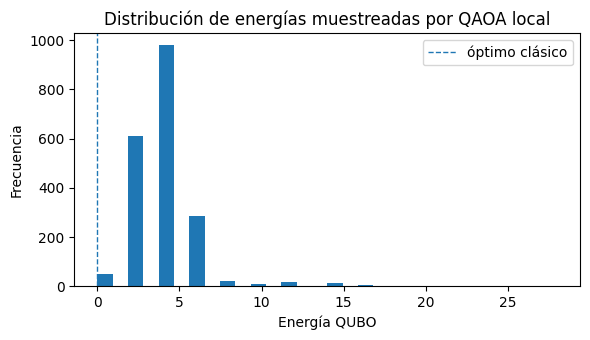

In [40]:
sampled_energies = energy_by_state[sampled_indices]

plt.figure(figsize=(6, 3.5))
plt.hist(sampled_energies, bins=30)
plt.axvline(best_energy_exact, linestyle="--", linewidth=1, label="óptimo clásico")
plt.xlabel("Energía QUBO")
plt.ylabel("Frecuencia")
plt.title("Distribución de energías muestreadas por QAOA local")
plt.legend()
plt.tight_layout()
plt.show()

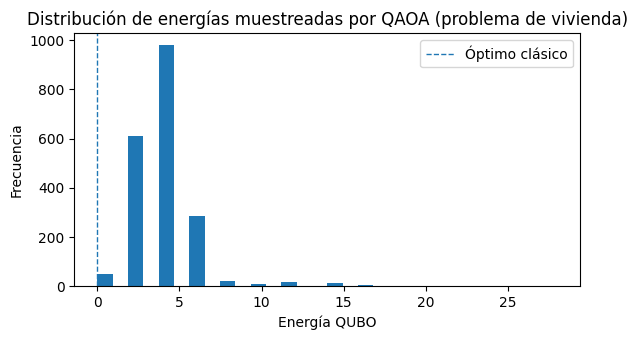

In [41]:
# ==========================================
# 30. Distribución de energías muestreadas
# ==========================================

"""
Objetivo:
Visualizar la distribución de energías QUBO obtenidas al muestrear
el estado QAOA simulado localmente.
"""

sampled_energies = energy_by_state[sampled_indices]

plt.figure(figsize=(6, 3.5))

plt.hist(sampled_energies, bins=30)

plt.axvline(
    best_energy_exact,
    linestyle="--",
    linewidth=1,
    label="Óptimo clásico"
)

plt.xlabel("Energía QUBO")
plt.ylabel("Frecuencia")

plt.title(
    "Distribución de energías muestreadas por QAOA (problema de vivienda)"
)

plt.legend()
plt.tight_layout()
plt.show()

## 31. Comparación final local

Objetivo: comparar clásico exacto contra QAOA local.

In [42]:
comparison_df = pd.DataFrame([
    {
        "método": "Clásico exacto",
        "energía": best_energy_exact,
        "score": best_score_exact,
        "factible": best_feasible_exact,
        "probabilidad_factible": np.nan,
        "probabilidad_óptimo": np.nan,
    },
    {
        "método": "QAOA local: mejor muestra",
        "energía": float(energy_by_state[best_observed_index]),
        "score": assignment_score(best_x_qaoa),
        "factible": is_feasible(best_x_qaoa),
        "probabilidad_factible": prob_feasible,
        "probabilidad_óptimo": prob_exact_optimum,
    },
])

display(comparison_df)

,método,energía,score,factible,probabilidad_factible,probabilidad_óptimo
0,Clásico exacto,0.0,0.0,True,NaN,NaN
1,QAOA local: mejor muestra,0.0,0.0,True,0.023258,0.000969


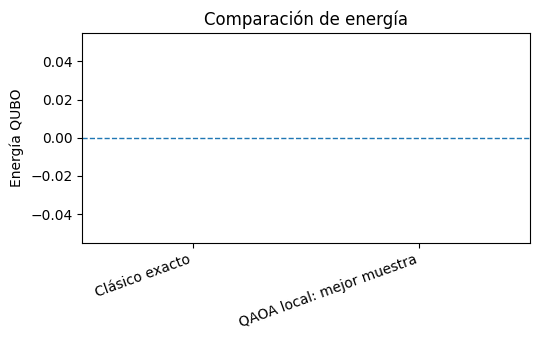

In [43]:
plt.figure(figsize=(5.5, 3.5))
plt.bar(comparison_df["método"], comparison_df["energía"])
plt.axhline(best_energy_exact, linestyle="--", linewidth=1)
plt.ylabel("Energía QUBO")
plt.title("Comparación de energía")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

,método,energía,score,factible,probabilidad_factible,probabilidad_óptimo
0,Clásico exacto,0.0,0.000000,True,NaN,NaN
1,QAOA local (mejor muestra),0.0,1.414405,True,0.023258,0.000969


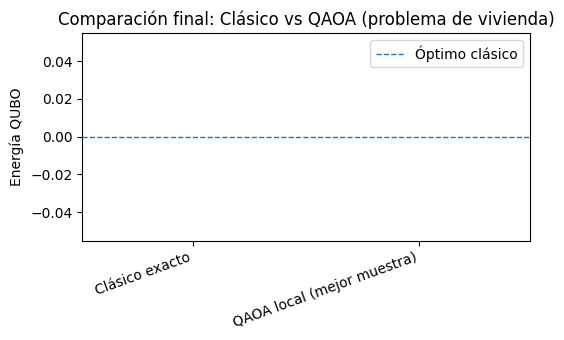

In [79]:
# ==========================================
# 31. Comparación final local
# ==========================================

"""
Objetivo:
Comparar la solución obtenida por búsqueda clásica exacta
contra la mejor solución observada mediante QAOA local.
"""

comparison_df = pd.DataFrame([
    {
        "método": "Clásico exacto",
        "energía": best_energy_exact,
        "score": best_score_exact,
        "factible": best_feasible_exact,
        "probabilidad_factible": np.nan,
        "probabilidad_óptimo": np.nan,
    },
    {
        "método": "QAOA local (mejor muestra)",
        "energía": float(energy_by_state[best_observed_index]),
        "score": assignment_score(best_x_qaoa),
        "factible": is_feasible(best_x_qaoa),
        "probabilidad_factible": prob_feasible,
        "probabilidad_óptimo": prob_exact_optimum,
    },
])

display(comparison_df)

plt.figure(figsize=(5.5, 3.5))

plt.bar(
    comparison_df["método"],
    comparison_df["energía"],
)

plt.axhline(
    best_energy_exact,
    linestyle="--",
    linewidth=1,
    label="Óptimo clásico"
)

plt.ylabel("Energía QUBO")

plt.title("Comparación final: Clásico vs QAOA (problema de vivienda)")

plt.xticks(rotation=20, ha="right")

plt.legend()

plt.tight_layout()

plt.show()

# Parte D — IBM Quantum opcional y comparación local vs hardware

Esta parte es avanzada y no es requisito para la calificación base. La ejecución en hardware real puede tener cola, ruido, límites de uso y condiciones asociadas a la cuenta de IBM Quantum.

El objetivo didáctico de esta sección es comparar:

```text
Clásico exacto      referencia óptima por fuerza bruta
QAOA local          simulación ideal y muestreo local
Hardware real       muestras obtenidas en un QPU de IBM Quantum
Pipeline híbrido    hardware o simulación con reparación clásica de muestras
```

La comparación solo será completa si `USAR_IBM_QUANTUM = True` y el job devuelve conteos. Para la entrega base, mantengan `USAR_IBM_QUANTUM = False`.

## 32. Configuración de IBM Quantum

Pega el token únicamente en una copia privada. No subas el token al repositorio de GitHub.

Para la entrega ordinaria del proyecto, deja `USAR_IBM_QUANTUM = False`.

In [ ]:
USAR_IBM_QUANTUM = False  #@param {type:"boolean"}
IBM_QUANTUM_TOKEN = ""  #@param {type:"string"}
IBM_INSTANCE_CRN = ""  #@param {type:"string"}

SHOTS_HARDWARE = 512  #@param {type:"integer"}
ESPERAR_RESULTADO_IBM = True  #@param {type:"boolean"}

hardware_backend_name = None
hardware_job_id = None
hardware_job_status = None
hardware_circuit_depth = None
hardware_circuit_ops = None
counts_hardware = None

if not USAR_IBM_QUANTUM:
    print("IBM Quantum desactivado. La entrega base se completa con QAOA local.")
elif not IBM_QUANTUM_TOKEN.strip():
    print("IBM Quantum activado, pero falta pegar el token en IBM_QUANTUM_TOKEN.")
else:
    print("IBM Quantum activado. Se intentará ejecutar la sección avanzada.")

## 33. Circuito QAOA para Qiskit

El circuito usa los mismos parámetros optimizados localmente. No se reoptimiza en hardware porque eso multiplicaría el número de jobs.

La capa de costo implementa la fase de la energía QUBO escalada, la misma que se usó en la simulación local.

In [45]:
def add_cost_layer_to_qiskit(qc: Any, gamma: float) -> None:
    """Agrega una capa de costo QUBO al circuito de Qiskit."""
    for k in range(N_VARS):
        coeff = Q[k, k]
        if abs(coeff) > 1e-12:
            qc.rz(-gamma * coeff / energy_scale, k)

    for k in range(N_VARS):
        for l in range(k + 1, N_VARS):
            coeff = Q[k, l]
            if abs(coeff) > 1e-12:
                qc.rz(-gamma * coeff / (2.0 * energy_scale), k)
                qc.rz(-gamma * coeff / (2.0 * energy_scale), l)
                qc.rzz(gamma * coeff / (2.0 * energy_scale), k, l)


def build_qiskit_qaoa_circuit(params: np.ndarray):
    """Construye el circuito QAOA medido para ejecutar con SamplerV2."""
    from qiskit import QuantumCircuit

    qc = QuantumCircuit(N_VARS)
    qc.h(range(N_VARS))

    for layer in range(QAOA_P):
        gamma = float(params[2 * layer])
        beta = float(params[2 * layer + 1])

        add_cost_layer_to_qiskit(qc, gamma)

        for k in range(N_VARS):
            qc.rx(2.0 * beta, k)

    qc.measure_all()
    return qc

In [46]:
# ==========================================
# 32. Circuito QAOA para Qiskit
# ==========================================

"""
Objetivo:
Construir el circuito QAOA equivalente en Qiskit usando los
parámetros óptimos obtenidos en la simulación local.

Cada qubit representa una variable binaria x_ij que indica
si el municipio i recibe la modalidad j de vivienda.

El operador de costo implementa la energía del modelo QUBO
escalada para evitar problemas numéricos en hardware.
"""

def add_cost_layer_to_qiskit(qc: Any, gamma: float) -> None:
    """
    Aplica la capa de costo del Hamiltoniano QUBO.
    """
    # Términos lineales
    for k in range(N_VARS):
        coeff = Q[k, k]

        if abs(coeff) > 1e-12:
            qc.rz(-gamma * coeff / energy_scale, k)

    # Términos cuadráticos
    for k in range(N_VARS):
        for l in range(k + 1, N_VARS):

            coeff = Q[k, l]

            if abs(coeff) > 1e-12:
                qc.rz(
                    -gamma * coeff / (2.0 * energy_scale),
                    k
                )
                qc.rz(
                    -gamma * coeff / (2.0 * energy_scale),
                    l
                )
                qc.rzz(
                    gamma * coeff / (2.0 * energy_scale),
                    k,
                    l,
                )


def build_qiskit_qaoa_circuit(params: np.ndarray):
    """
    Construye el circuito QAOA para ejecución en Qiskit SamplerV2.
    """
    from qiskit import QuantumCircuit

    qc = QuantumCircuit(N_VARS)

    # Estado inicial |+>
    qc.h(range(N_VARS))

    for layer in range(QAOA_P):

        gamma = float(params[2 * layer])
        beta = float(params[2 * layer + 1])

        add_cost_layer_to_qiskit(qc, gamma)

        # Mixer
        for k in range(N_VARS):
            qc.rx(2.0 * beta, k)

    qc.measure_all()

    return qc

## 33. Extracción de conteos del Sampler

El `SamplerV2` devuelve resultados por registros clásicos. Esta función intenta extraer los conteos de forma robusta para poder compararlos con el muestreo local.

In [47]:
# ==========================================
# 33. Extracción de conteos del Sampler
# ==========================================

"""
Objetivo:
Extraer los bitstrings medidos por Qiskit SamplerV2 para
compararlos con los resultados obtenidos en la simulación
local del problema de asignación de modalidades de vivienda.

La función es compatible con distintos formatos de salida
del SamplerV2.
"""

def extract_counts_from_sampler_result(pub_result: Any) -> dict[str, int]:
    """Extrae conteos de un resultado de SamplerV2."""
    data = getattr(pub_result, "data", None)
    if data is None:
        raise ValueError("El resultado no contiene el atributo data.")

    for register_name in ["meas", "c", "creg"]:
        if hasattr(data, register_name):
            register_data = getattr(data, register_name)

            if hasattr(register_data, "get_counts"):
                return dict(register_data.get_counts())

            if hasattr(register_data, "get_bitstrings"):
                return dict(Counter(register_data.get_bitstrings()))

    for attribute_name in dir(data):
        if attribute_name.startswith("_"):
            continue

        try:
            candidate = getattr(data, attribute_name)
        except Exception:
            continue

        if hasattr(candidate, "get_counts"):
            return dict(candidate.get_counts())

        if hasattr(candidate, "get_bitstrings"):
            return dict(Counter(candidate.get_bitstrings()))

    raise ValueError("No fue posible extraer conteos del resultado de SamplerV2.")

## 34. Ejecución opcional en hardware real

Esta celda envía un solo circuito QAOA a un backend real. Si `ESPERAR_RESULTADO_IBM = True`, la celda esperará a que el job termine para obtener los conteos.

Si la cola es larga, puede ponerse `ESPERAR_RESULTADO_IBM = False`, guardar el `job_id` y recuperar el resultado después.

In [48]:
if USAR_IBM_QUANTUM:
    import os
    from qiskit.transpiler import generate_preset_pass_manager
    from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

    token = IBM_QUANTUM_TOKEN.strip() or os.getenv("IBM_QUANTUM_TOKEN", "").strip()
    if not token:
        raise RuntimeError("Pega tu token en IBM_QUANTUM_TOKEN o define la variable de entorno IBM_QUANTUM_TOKEN.")

    service_kwargs = {
        "channel": "ibm_quantum_platform",
        "token": token,
    }
    if IBM_INSTANCE_CRN.strip():
        service_kwargs["instance"] = IBM_INSTANCE_CRN.strip()

    service = QiskitRuntimeService(**service_kwargs)
    backend = service.least_busy(operational=True, simulator=False, min_num_qubits=N_VARS)

    backend_name_attr = getattr(backend, "name", None)
    hardware_backend_name = backend_name_attr() if callable(backend_name_attr) else str(backend_name_attr)

    circuit_hardware = build_qiskit_qaoa_circuit(best_params)

    pass_manager = generate_preset_pass_manager(
        optimization_level=1,
        backend=backend,
        seed_transpiler=SEED,
    )
    circuit_isa = pass_manager.run(circuit_hardware)

    hardware_circuit_depth = int(circuit_isa.depth())
    hardware_circuit_ops = dict(circuit_isa.count_ops())

    sampler = Sampler(mode=backend)
    job = sampler.run([circuit_isa], shots=SHOTS_HARDWARE)

    hardware_job_id = job.job_id()
    hardware_job_status = str(job.status())

    print("Backend:", hardware_backend_name)
    print("Job ID:", hardware_job_id)
    print("Estado inicial:", hardware_job_status)
    print("Profundidad ISA:", hardware_circuit_depth)
    print("Operaciones ISA:", hardware_circuit_ops)

    if ESPERAR_RESULTADO_IBM:
        hardware_result = job.result()
        pub_result = hardware_result[0]
        counts_hardware = normalizar_conteos(extract_counts_from_sampler_result(pub_result), N_VARS)
        hardware_job_status = str(job.status())

        print("Estado final:", hardware_job_status)
        print("Shots recibidos:", sum(counts_hardware.values()))
        print("Bitstrings distintos:", len(counts_hardware))
else:
    print("No se envió ningún job a IBM Quantum.")

NameError: name 'USAR_IBM_QUANTUM' is not defined

## 35. Reparación clásica conservadora

El mixer estándar de QAOA no preserva automáticamente las restricciones de asignación. Por eso pueden aparecer bitstrings no factibles.

La reparación clásica proyecta cada bitstring observado al conjunto de asignaciones uno-a-uno factibles. Debe reportarse como **postprocesamiento híbrido**, no como salida cuántica pura.

In [49]:
REPARAR_MUESTRAS = True
REPAIR_SAMPLE_BONUS = 0.15


def repair_x_to_feasible_assignment(x: np.ndarray, sample_bonus: float = REPAIR_SAMPLE_BONUS) -> np.ndarray:
    """Proyecta un bitstring observado a una asignación factible."""
    observed_matrix = assignment_matrix(x)

    s_min = float(np.min(S))
    s_max = float(np.max(S))
    if abs(s_max - s_min) < 1e-12:
        S_norm = np.zeros_like(S, dtype=float)
    else:
        S_norm = (S - s_min) / (s_max - s_min)

    projection_score = S_norm + sample_bonus * observed_matrix
    row_ind, col_ind = linear_sum_assignment(-projection_score)

    repaired = np.zeros(N_VARS, dtype=int)
    for i, j in zip(row_ind, col_ind):
        repaired[var_index(i, j)] = 1

    return repaired


def repair_counts_to_counts(counts: dict[str, int] | None) -> dict[str, int] | None:
    """Aplica la reparación clásica a todos los bitstrings de un diccionario de conteos."""
    normalized = normalizar_conteos(counts, N_VARS)
    if normalized is None:
        return None

    repaired_counts = Counter()
    for bitstring, count in normalized.items():
        x = decode_qiskit_bitstring(bitstring, N_VARS)
        x_repaired = repair_x_to_feasible_assignment(x)
        repaired_counts[x_to_qiskit_bitstring(x_repaired)] += int(count)

    return dict(repaired_counts)


counts_local_repaired = repair_counts_to_counts(counts_local) if REPARAR_MUESTRAS else None
counts_hardware_repaired = repair_counts_to_counts(counts_hardware) if (REPARAR_MUESTRAS and counts_hardware is not None) else None

print("Reparación local disponible:", counts_local_repaired is not None)
print("Reparación hardware disponible:", counts_hardware_repaired is not None)

NameError: name 'counts_hardware' is not defined

In [50]:
# ==========================================
# 35. Reparación clásica conservadora
# ==========================================

"""
Objetivo:
Corregir bitstrings no factibles obtenidos por QAOA.

El mixer estándar de QAOA no preserva automáticamente las
restricciones del problema de asignación de modalidades de
vivienda a municipios (cada municipio recibe exactamente una
modalidad y cada modalidad se asigna exactamente una vez).

La reparación clásica proyecta cada bitstring observado al
conjunto de asignaciones factibles utilizando el algoritmo
húngaro (Hungarian Algorithm).

Este procedimiento constituye un postprocesamiento híbrido
clásico y no debe interpretarse como parte de la salida
cuántica pura.
"""

REPARAR_MUESTRAS = True
REPAIR_SAMPLE_BONUS = 0.15


def repair_x_to_feasible_assignment(
    x: np.ndarray,
    sample_bonus: float = REPAIR_SAMPLE_BONUS,
) -> np.ndarray:
    """
    Proyecta un bitstring observado a una asignación factible
    Municipio × Modalidad mediante el algoritmo húngaro.
    """

    observed_assignment = assignment_matrix(x)

    # Normalizar la matriz de scores
    s_min = float(np.min(S))
    s_max = float(np.max(S))

    if abs(s_max - s_min) < 1e-12:
        S_norm = np.zeros_like(S, dtype=float)
    else:
        S_norm = (S - s_min) / (s_max - s_min)

    # Favorecer las asignaciones ya observadas durante el muestreo
    projection_score = (
        S_norm +
        sample_bonus * observed_assignment
    )

    # Resolver el problema de asignación
    row_ind, col_ind = linear_sum_assignment(
        -projection_score
    )

    repaired = np.zeros(N_VARS, dtype=int)

    for i, j in zip(row_ind, col_ind):
        repaired[var_index(i, j)] = 1

    return repaired


def repair_counts_to_counts(
    counts: dict[str, int] | None
) -> dict[str, int] | None:
    """
    Aplica la reparación clásica a todos los bitstrings
    observados durante el muestreo.
    """

    normalized = normalizar_conteos(
        counts,
        N_VARS,
    )

    if normalized is None:
        return None

    repaired_counts = Counter()

    for bitstring, count in normalized.items():

        x = decode_qiskit_bitstring(
            bitstring,
            N_VARS,
        )

        x_repaired = repair_x_to_feasible_assignment(x)

        repaired_counts[
            x_to_qiskit_bitstring(x_repaired)
        ] += int(count)

    return dict(repaired_counts)


# ==========================================
# Reparación de muestras locales y hardware
# ==========================================

counts_local_repaired = (
    repair_counts_to_counts(counts_local)
    if REPARAR_MUESTRAS
    else None
)

counts_hardware_repaired = (
    repair_counts_to_counts(counts_hardware)
    if (
        REPARAR_MUESTRAS
        and counts_hardware is not None
    )
    else None
)

print(
    "Reparación de muestras locales disponible:",
    counts_local_repaired is not None,
)

print(
    "Reparación de muestras de hardware disponible:",
    counts_hardware_repaired is not None,
)

NameError: name 'counts_hardware' is not defined

## 36. Tabla comparativa de métodos

La comparación usa la energía QUBO como métrica principal. El score solo debe interpretarse si la solución es factible.

In [51]:
# ==========================================
# 36. Tabla comparativa de métodos
# ==========================================

"""
Objetivo:
Comparar el desempeño de los distintos métodos utilizados para resolver
el problema de asignación de modalidades de vivienda.

La energía QUBO es la métrica principal de comparación. El score de
asignación únicamente debe interpretarse cuando la solución satisface
las restricciones del problema (matching 4×4).
"""

def counts_to_dataframe(counts: dict[str, int] | None, method_name: str) -> pd.DataFrame:
    """Convierte conteos de muestreo en una tabla evaluada con el QUBO."""
    normalized = normalizar_conteos(counts, N_VARS)
    if normalized is None or len(normalized) == 0:
        return pd.DataFrame()

    total_shots = int(sum(normalized.values()))
    rows = []

    for bitstring, count in normalized.items():
        x = decode_qiskit_bitstring(bitstring, N_VARS)
        rows.append({
            "método": method_name,
            "bitstring": bitstring,
            "conteos": int(count),
            "probabilidad": int(count) / total_shots,
            "energía_QUBO": float(qubo_energy(x, Q, qubo_offset)),
            "score": float(assignment_score(x, S)),
            "factible": bool(is_feasible(x)),
            "es_óptimo_clásico": bool(np.array_equal(x, best_x_exact)),
        })

    df = pd.DataFrame(rows)
    return df.sort_values(
        by=["energía_QUBO", "score", "probabilidad"],
        ascending=[True, False, False],
    ).reset_index(drop=True)


def summarize_counts_method(counts: dict[str, int] | None, method_name: str) -> dict[str, Any] | None:
    """Resume la distribución de conteos de un método."""
    normalized = normalizar_conteos(counts, N_VARS)
    df = counts_to_dataframe(normalized, method_name)
    if df.empty:
        return None

    total_shots = int(sum(normalized.values()))
    best = df.iloc[0]

    feasible_counts = int(df.loc[df["factible"], "conteos"].sum())
    optimal_counts = int(df.loc[df["es_óptimo_clásico"], "conteos"].sum())

    expected_energy = float(np.sum(df["energía_QUBO"] * df["probabilidad"]))
    expected_score = float(np.sum(df["score"] * df["probabilidad"]))

    return {
        "método": method_name,
        "shots": total_shots,
        "energía_mejor_observada": float(best["energía_QUBO"]),
        "energía_media_muestreo": expected_energy,
        "score_mejor_observado": float(best["score"]),
        "score_medio_muestreo": expected_score,
        "factible_mejor_observado": bool(best["factible"]),
        "probabilidad_factible": feasible_counts / total_shots,
        "probabilidad_óptimo_clásico": optimal_counts / total_shots,
        "bitstring_mejor": str(best["bitstring"]),
    }


summary_rows = [
    {
        "método": "Clásico exacto",
        "shots": np.nan,
        "energía_mejor_observada": best_energy_exact,
        "energía_media_muestreo": np.nan,
        "score_mejor_observado": best_score_exact,
        "score_medio_muestreo": np.nan,
        "factible_mejor_observado": best_feasible_exact,
        "probabilidad_factible": np.nan,
        "probabilidad_óptimo_clásico": np.nan,
        "bitstring_mejor": x_to_qiskit_bitstring(best_x_exact),
    }
]

for method_name, counts_obj in [
    ("QAOA local", counts_local),
    ("QAOA local reparado", counts_local_repaired),
    ("Hardware real", counts_hardware),
    ("Hardware real reparado", counts_hardware_repaired),
]:
    row = summarize_counts_method(counts_obj, method_name)
    if row is not None:
        summary_rows.append(row)

comparacion_metodos_df = pd.DataFrame(summary_rows)
display(comparacion_metodos_df)

NameError: name 'counts_hardware' is not defined

## 37. Gráficas comparativas

Estas gráficas permiten contrastar QAOA local contra hardware real cuando hay conteos disponibles.

Interpretación mínima:

- Menor energía QUBO es mejor.
- Mayor probabilidad de óptimo clásico es mejor.
- Mayor probabilidad factible es mejor.
- La reparación clásica se analiza por separado.

In [52]:
# ==========================================
# 37. Gráficas comparativas
# ==========================================

"""
Objetivo:
Comparar el desempeño de los distintos métodos empleados
para resolver el problema de asignación de modalidades de
vivienda mediante el modelo QUBO.

Interpretación:

- Menor energía QUBO indica una mejor solución.
- Mayor probabilidad del óptimo clásico indica un mejor desempeño.
- Mayor probabilidad de soluciones factibles refleja un mejor
  cumplimiento de las restricciones del problema.
- Los resultados con reparación clásica corresponden a un
  postprocesamiento híbrido y deben analizarse por separado.
"""


def plot_metric_bar(df: pd.DataFrame, metric: str, ylabel: str, title: str, reference: float | None = None) -> None:
    """Grafica una métrica por método."""
    plot_df = df.dropna(subset=[metric]).copy()
    if plot_df.empty:
        print(f"No hay datos para graficar: {metric}")
        return

    plt.figure(figsize=(8.5, 4.0))
    plt.bar(plot_df["método"], plot_df[metric])

    if reference is not None:
        plt.axhline(reference, linestyle="--", linewidth=1)

    plt.ylabel(ylabel)
    plt.title(title)
    plt.xticks(rotation=25, ha="right")
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_metric_bar(
    comparacion_metodos_df,
    "energía_mejor_observada",
    "Energía QUBO",
    "Mejor energía observada por método; menor es mejor",
    reference=best_energy_exact,
)

plot_metric_bar(
    comparacion_metodos_df,
    "energía_media_muestreo",
    "Energía QUBO media",
    "Energía media de muestreo; menor es mejor",
    reference=best_energy_exact,
)

plot_metric_bar(
    comparacion_metodos_df,
    "probabilidad_óptimo_clásico",
    "Probabilidad",
    "Probabilidad de observar el óptimo clásico",
)

plot_metric_bar(
    comparacion_metodos_df,
    "probabilidad_factible",
    "Probabilidad",
    "Probabilidad de obtener soluciones factibles",
)

NameError: name 'comparacion_metodos_df' is not defined

## 38. Curvas acumuladas local vs hardware

El `Sampler` entrega conteos agregados, no el orden temporal real de cada shot. Para construir curvas acumuladas se expande la distribución de conteos y se mezcla con una semilla fija.

La curva responde esta pregunta: si acumulamos muestras de esta distribución, ¿qué tan rápido aparece una solución buena?

In [53]:
CURVE_RANDOM_SEED = SEED + 9001
CURVE_MAX_POINTS = 250


def expand_counts_to_samples(counts: dict[str, int] | None, seed: int) -> list[str]:
    """Expande conteos agregados a una lista mezclada de bitstrings."""
    normalized = normalizar_conteos(counts, N_VARS)
    if normalized is None or len(normalized) == 0:
        return []

    samples = []
    for bitstring, count in sorted(normalized.items()):
        samples.extend([bitstring] * int(count))

    local_rng = np.random.default_rng(seed)
    local_rng.shuffle(samples)
    return samples


def cumulative_curve_from_counts(counts: dict[str, int] | None, method_name: str, seed_offset: int = 0) -> pd.DataFrame:
    """Construye curvas acumuladas de desempeño a partir de conteos."""
    samples = expand_counts_to_samples(counts, CURVE_RANDOM_SEED + seed_offset)
    if not samples:
        return pd.DataFrame()

    n_samples = len(samples)
    n_points = min(CURVE_MAX_POINTS, n_samples)
    checkpoints = set(np.unique(np.linspace(1, n_samples, n_points, dtype=int)).tolist())

    best_energy_so_far = float("inf")
    feasible_count = 0
    optimal_count = 0
    rows = []

    for shot_index, bitstring in enumerate(samples, start=1):
        x = decode_qiskit_bitstring(bitstring, N_VARS)
        energy = float(qubo_energy(x, Q, qubo_offset))
        best_energy_so_far = min(best_energy_so_far, energy)

        if is_feasible(x):
            feasible_count += 1

        if np.array_equal(x, best_x_exact):
            optimal_count += 1

        if shot_index in checkpoints:
            gap_pct = 100.0 * (best_energy_so_far - best_energy_exact) / abs(best_energy_exact) if best_energy_exact != 0 else np.nan
            rows.append({
                "método": method_name,
                "shots_acumulados": shot_index,
                "mejor_energía_acumulada": best_energy_so_far,
                "brecha_mejor_energía_%": max(0.0, float(gap_pct)) if np.isfinite(gap_pct) else np.nan,
                "factibilidad_%": 100.0 * feasible_count / shot_index,
                "óptimo_observado_%": 100.0 * optimal_count / shot_index,
            })

    return pd.DataFrame(rows)


curve_dfs = []
for seed_offset, (method_name, counts_obj) in enumerate([
    ("QAOA local", counts_local),
    ("QAOA local reparado", counts_local_repaired),
    ("Hardware real", counts_hardware),
    ("Hardware real reparado", counts_hardware_repaired),
]):
    curve_df = cumulative_curve_from_counts(counts_obj, method_name, seed_offset)
    if not curve_df.empty:
        curve_dfs.append(curve_df)

curvas_desempeno_df = pd.concat(curve_dfs, ignore_index=True) if curve_dfs else pd.DataFrame()
display(curvas_desempeno_df.head())

NameError: name 'counts_hardware' is not defined

In [81]:
def plot_curve(metric: str, ylabel: str, title: str, reference: float | None = None) -> None:
    """Grafica una curva acumulada por método."""
    if curvas_desempeno_df.empty:
        print("No hay curvas disponibles.")
        return

    plt.figure(figsize=(8.5, 4.5))

    if reference is not None:
        plt.axhline(reference, linestyle="--", linewidth=1, label="Referencia clásica")

    for method_name in curvas_desempeno_df["método"].unique():
        method_df = curvas_desempeno_df[curvas_desempeno_df["método"] == method_name]
        plt.plot(method_df["shots_acumulados"], method_df[metric], linewidth=2, label=method_name)

    plt.xlabel("Shots acumulados")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_curve(
    "mejor_energía_acumulada",
    "Mejor energía QUBO acumulada",
    "Curva acumulada de mejor energía; menor es mejor",
    reference=best_energy_exact,
)

plot_curve(
    "brecha_mejor_energía_%",
    "Brecha energética (%)",
    "Curva acumulada de brecha energética; menor es mejor",
    reference=0.0,
)

plot_curve(
    "factibilidad_%",
    "Muestras factibles acumuladas (%)",
    "Curva acumulada de factibilidad; mayor es mejor",
    reference=100.0,
)

plot_curve(
    "óptimo_observado_%",
    "Óptimo clásico observado acumulado (%)",
    "Curva acumulada de observación del óptimo; mayor es mejor",
    reference=100.0,
)

NameError: name 'curvas_desempeno_df' is not defined

## 39. Lectura automática local vs hardware

Esta lectura no reemplaza el análisis del equipo. Sirve para detectar rápidamente si hardware real produjo una distribución comparable, peor o mejor que QAOA local en esta instancia pequeña.

In [80]:
def get_comparison_row(method_name: str) -> pd.Series | None:
    selected = comparacion_metodos_df[comparacion_metodos_df["método"] == method_name]
    if selected.empty:
        return None
    return selected.iloc[0]


local_row = get_comparison_row("QAOA local")
hardware_row = get_comparison_row("Hardware real")
local_repaired_row = get_comparison_row("QAOA local reparado")
hardware_repaired_row = get_comparison_row("Hardware real reparado")

print("Lectura automática:")

if hardware_row is None:
    print("- No hay conteos de hardware real. Para completar esta comparación, activa IBM Quantum y ejecuta la sección avanzada.")
else:
    if hardware_row["energía_mejor_observada"] <= local_row["energía_mejor_observada"]:
        print("- Hardware real igualó o mejoró la mejor energía observada por QAOA local.")
    else:
        print("- QAOA local obtuvo mejor energía observada que hardware real.")

    if hardware_row["probabilidad_factible"] >= local_row["probabilidad_factible"]:
        print("- Hardware real tuvo igual o mayor proporción de muestras factibles que QAOA local.")
    else:
        print("- QAOA local tuvo mayor proporción de muestras factibles que hardware real.")

    if hardware_row["probabilidad_óptimo_clásico"] >= local_row["probabilidad_óptimo_clásico"]:
        print("- Hardware real observó el óptimo clásico con igual o mayor frecuencia que QAOA local.")
    else:
        print("- QAOA local observó el óptimo clásico con mayor frecuencia que hardware real.")

if hardware_repaired_row is not None and local_repaired_row is not None:
    print("\nLectura con reparación clásica:")
    if hardware_repaired_row["energía_mejor_observada"] <= local_repaired_row["energía_mejor_observada"]:
        print("- Hardware reparado igualó o mejoró la mejor energía local reparada.")
    else:
        print("- La reparación local obtuvo mejor energía que la reparación de hardware.")

print("\nRegla de reporte:")
print("- Contra el clásico exacto, QAOA y hardware solo pueden empatar el óptimo en esta instancia pequeña.")
print("- Si la mejora aparece solo después de reparación, debe reportarse como mejora del pipeline híbrido, no del hardware aislado.")

NameError: name 'comparacion_metodos_df' is not defined

# Parte E — Entrega obligatoria en GitHub

La entrega final es el enlace al repositorio GitHub del estudiante o del equipo. El repositorio debe contener el CSV en `data/`, un `README.md` justificando el dataset y el archivo `.ipynb` listo para abrirse en Google Colab.

## 40. Checklist técnico del repositorio

Antes de entregar el enlace de GitHub, verifiquen:

```text
[ ] El repositorio fue creado desde el perfil GitHub del estudiante, del equipo o de un representante.
[ ] Existe una carpeta data/ en la raíz del repositorio.
[ ] data/ contiene dataset_real_4x4.csv o un CSV equivalente claramente documentado.
[ ] Existe README.md en la raíz del repositorio.
[ ] README.md justifica fuente, institución, URL, licencia o condiciones de uso y fecha de consulta.
[ ] README.md define A, B, x_ij, S_ij y las restricciones.
[ ] README.md explica por qué el problema es matching bipartito.
[ ] README.md explica por qué el modelo puede formularse como QUBO.
[ ] README.md compara solución clásica exacta contra QAOA local.
[ ] Si se ejecutó IBM Quantum, README.md compara QAOA local contra hardware real.
[ ] Si se usó reparación clásica, README.md la reporta como postprocesamiento híbrido.
[ ] Existe un archivo .ipynb que se puede abrir en Google Colab.
[ ] El archivo .ipynb ejecuta todas las celdas en orden sin errores intermedios.
[ ] No hay tokens, credenciales ni datos sensibles en el repositorio.
[ ] La instancia molecular de ejemplo fue reemplazada por el dataset real o semi-real del equipo.
[ ] La advertencia ética y las limitaciones del modelo están explícitas.
```

La instancia molecular de ejemplo no cuenta como dataset final. Su función es verificar que el código funciona antes de insertar el dataset real o semi-real.

## 41. Interpretación mínima del resultado

El equipo debe responder en el `README.md`:

1. ¿Cuál fue la mejor asignación encontrada?
2. ¿Cuál fue su score en el dominio?
3. ¿La asignación cumple todas las restricciones?
4. ¿QAOA local observó el óptimo clásico?
5. ¿Qué tan frecuente fue observar soluciones factibles?
6. ¿Qué limitaciones tiene el modelo $4\times 4$?
7. ¿Qué cambiaría si el dataset creciera?
8. ¿Qué riesgos éticos existen y cómo se mitigaron?
9. Si se usó hardware real, ¿cómo compara contra QAOA local?
10. Si se usó reparación clásica, ¿qué parte del resultado corresponde al postprocesamiento híbrido?

La salida de QAOA no debe presentarse como una recomendación real de política pública, salud, empleo, vivienda o asignación de recursos.

In [54]:
print("Resumen automático")
print("------------------")
print("Instancia:", NOMBRE_INSTANCIA)
print("Dataset:", f"{len(A_df)} x {len(B_df)}")
print("Mejor energía clásica:", best_energy_exact)
print("Mejor score clásico:", best_score_exact)
print("Mejor asignación clásica:")
display(selected_pairs(best_x_exact))

print("QAOA local")
print("----------")
print("Energía esperada:", best_expected_energy)
print("Mejor energía observada:", float(energy_by_state[best_observed_index]))
print("Probabilidad ideal de factibilidad:", prob_feasible)
print("Probabilidad ideal del óptimo clásico:", prob_exact_optimum)

if counts_hardware is not None:
    print("Hardware real")
    print("-------------")
    print("Backend:", hardware_backend_name)
    print("Job ID:", hardware_job_id)
    print("Shots:", sum(counts_hardware.values()))
    print("Profundidad ISA:", hardware_circuit_depth)
else:
    print("Hardware real: no ejecutado.")

if USANDO_DATASET_MOLECULAR_DE_EJEMPLO:
    print("\nAdvertencia: la instancia molecular es solo de ejemplo. Para la entrega final debe sustituirse por el dataset real o semi-real del equipo.")
else:
    print("\nDataset real/semi-real activo. Verifiquen que el README.md documente la fuente y la construcción de S.")

Resumen automático
------------------


NameError: name 'NOMBRE_INSTANCIA' is not defined

## 42. Referencias técnicas sugeridas

Para profundizar:

- QUBO e Ising Hamiltonians.
- Matching bipartito y problema de asignación.
- QAOA y algoritmos variacionales.
- Mixers que preservan restricciones.
- Penalizaciones cuadráticas.
- Mitigación de error y transpilación en hardware real.